# Importing libraries

In [24]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import shap
import seaborn as sns


import math

from sklearn.utils import resample
from sklearn.metrics import recall_score, precision_score, fbeta_score
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

In [2]:
data_csv = pd.read_csv(r"C:\Users\ismai\Downloads\archive (16)\equipment_anomaly_data.csv")

C:\Users\ismai\AppData\Local\Temp\ipykernel_36128\2531965560.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ismai\AppData\Local\Temp\ipykernel_36128\2531965560.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ismai\AppData\Local\Temp\ipykernel_36128\2531965560.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ismai\AppData\Local\Temp\ipykernel_36128\2531965560.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

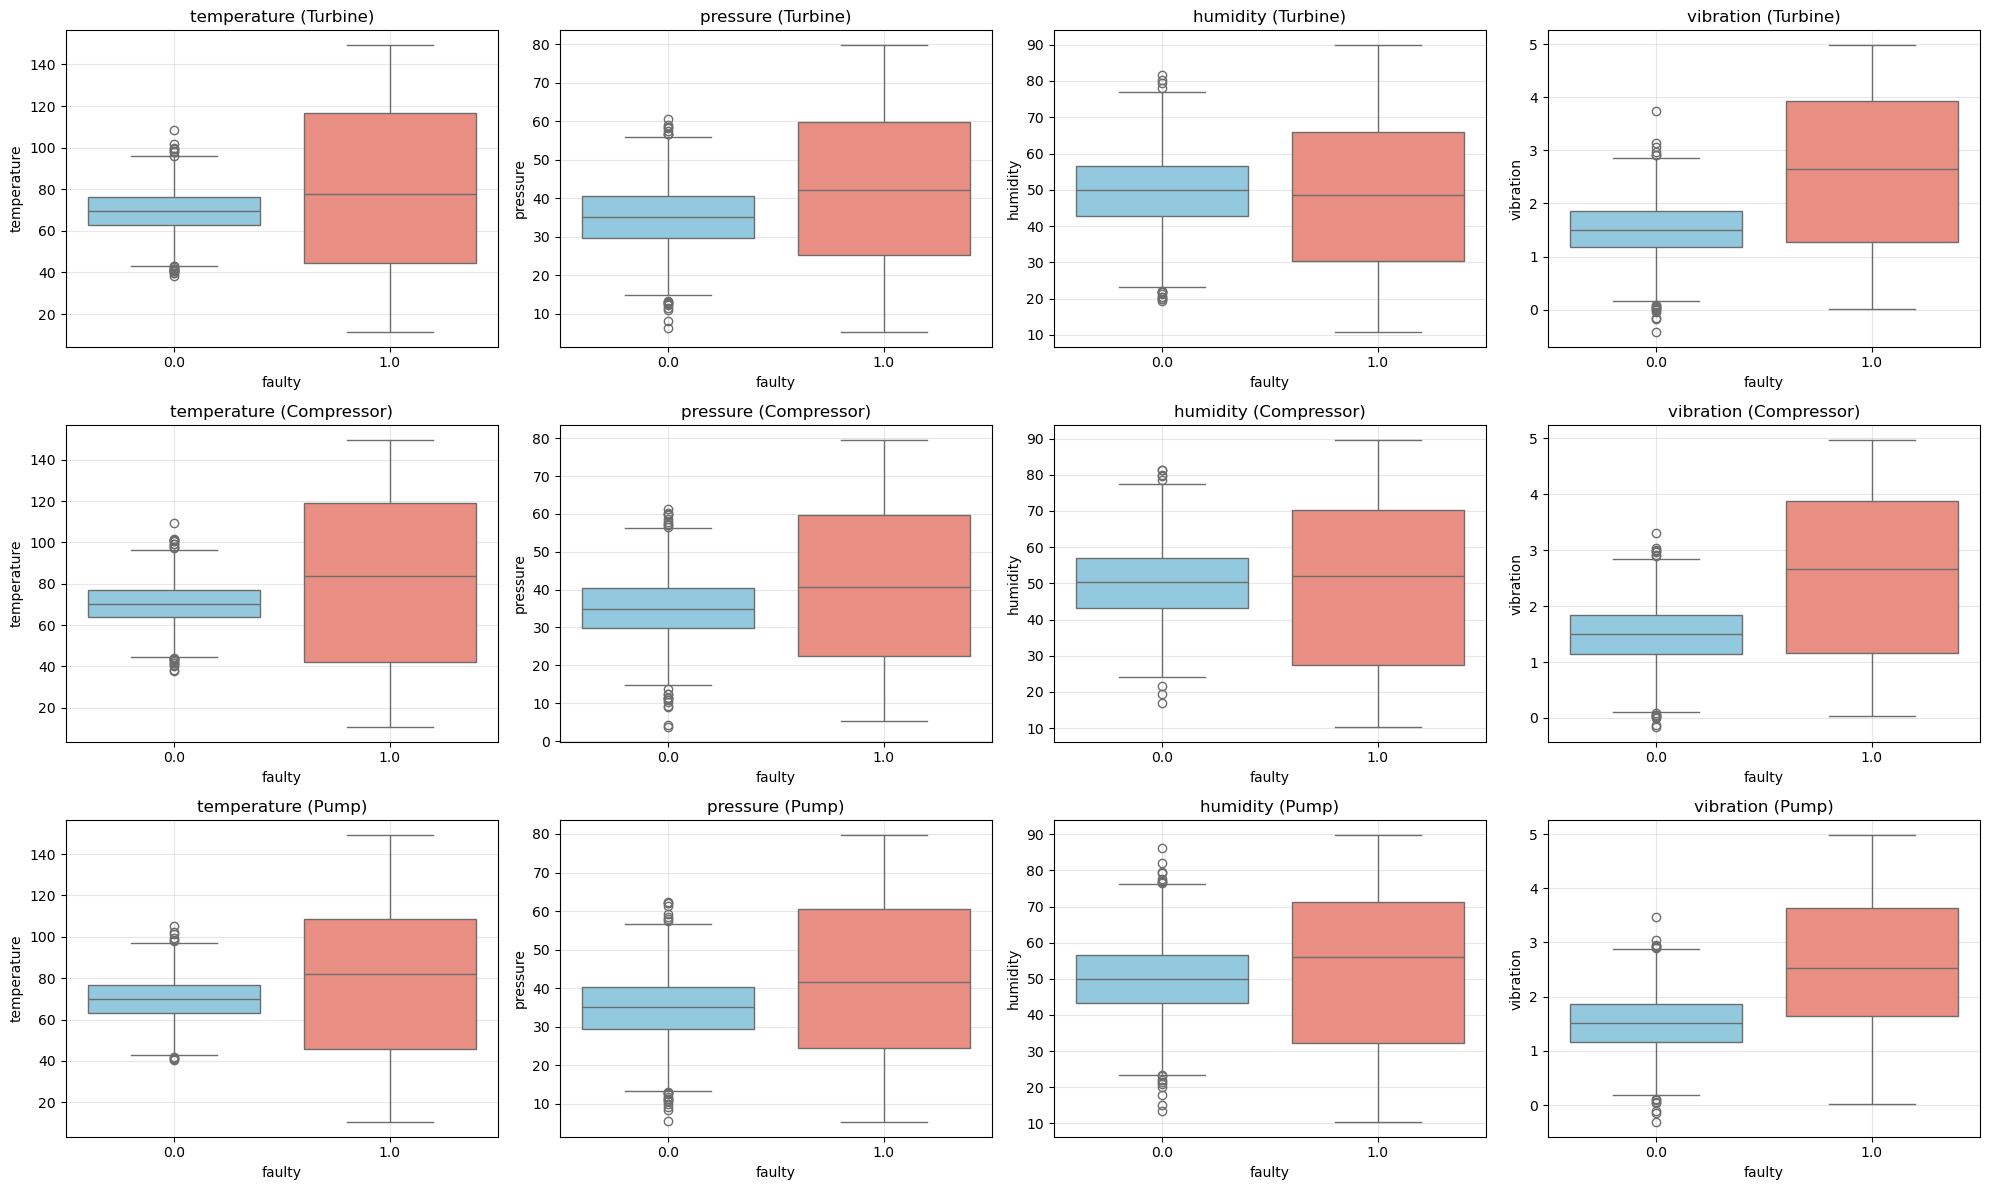

In [3]:


target_col = 'faulty'
equipment_col = 'equipment'

variables = ['temperature', 'pressure', 'humidity', 'vibration']
equipment_types = data_csv[equipment_col].unique()

# Create grid: rows = equipment types, cols = variables
fig, axes = plt.subplots(
    len(equipment_types), 
    len(variables),
    figsize=(5*len(variables), 4*len(equipment_types))
)

# If only one equipment type exists, fix axis shape
if len(equipment_types) == 1:
    axes = axes.reshape(1, -1)

for row, eq in enumerate(equipment_types):
    
    subset = data_csv[data_csv[equipment_col] == eq]
    
    for col, var in enumerate(variables):
        
        sns.boxplot(
            x=target_col,
            y=var,
            data=subset,
            palette=['skyblue', 'salmon'],
            ax=axes[row, col]
        )
        
        axes[row, col].set_title(f"{var} ({eq})")
        axes[row, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

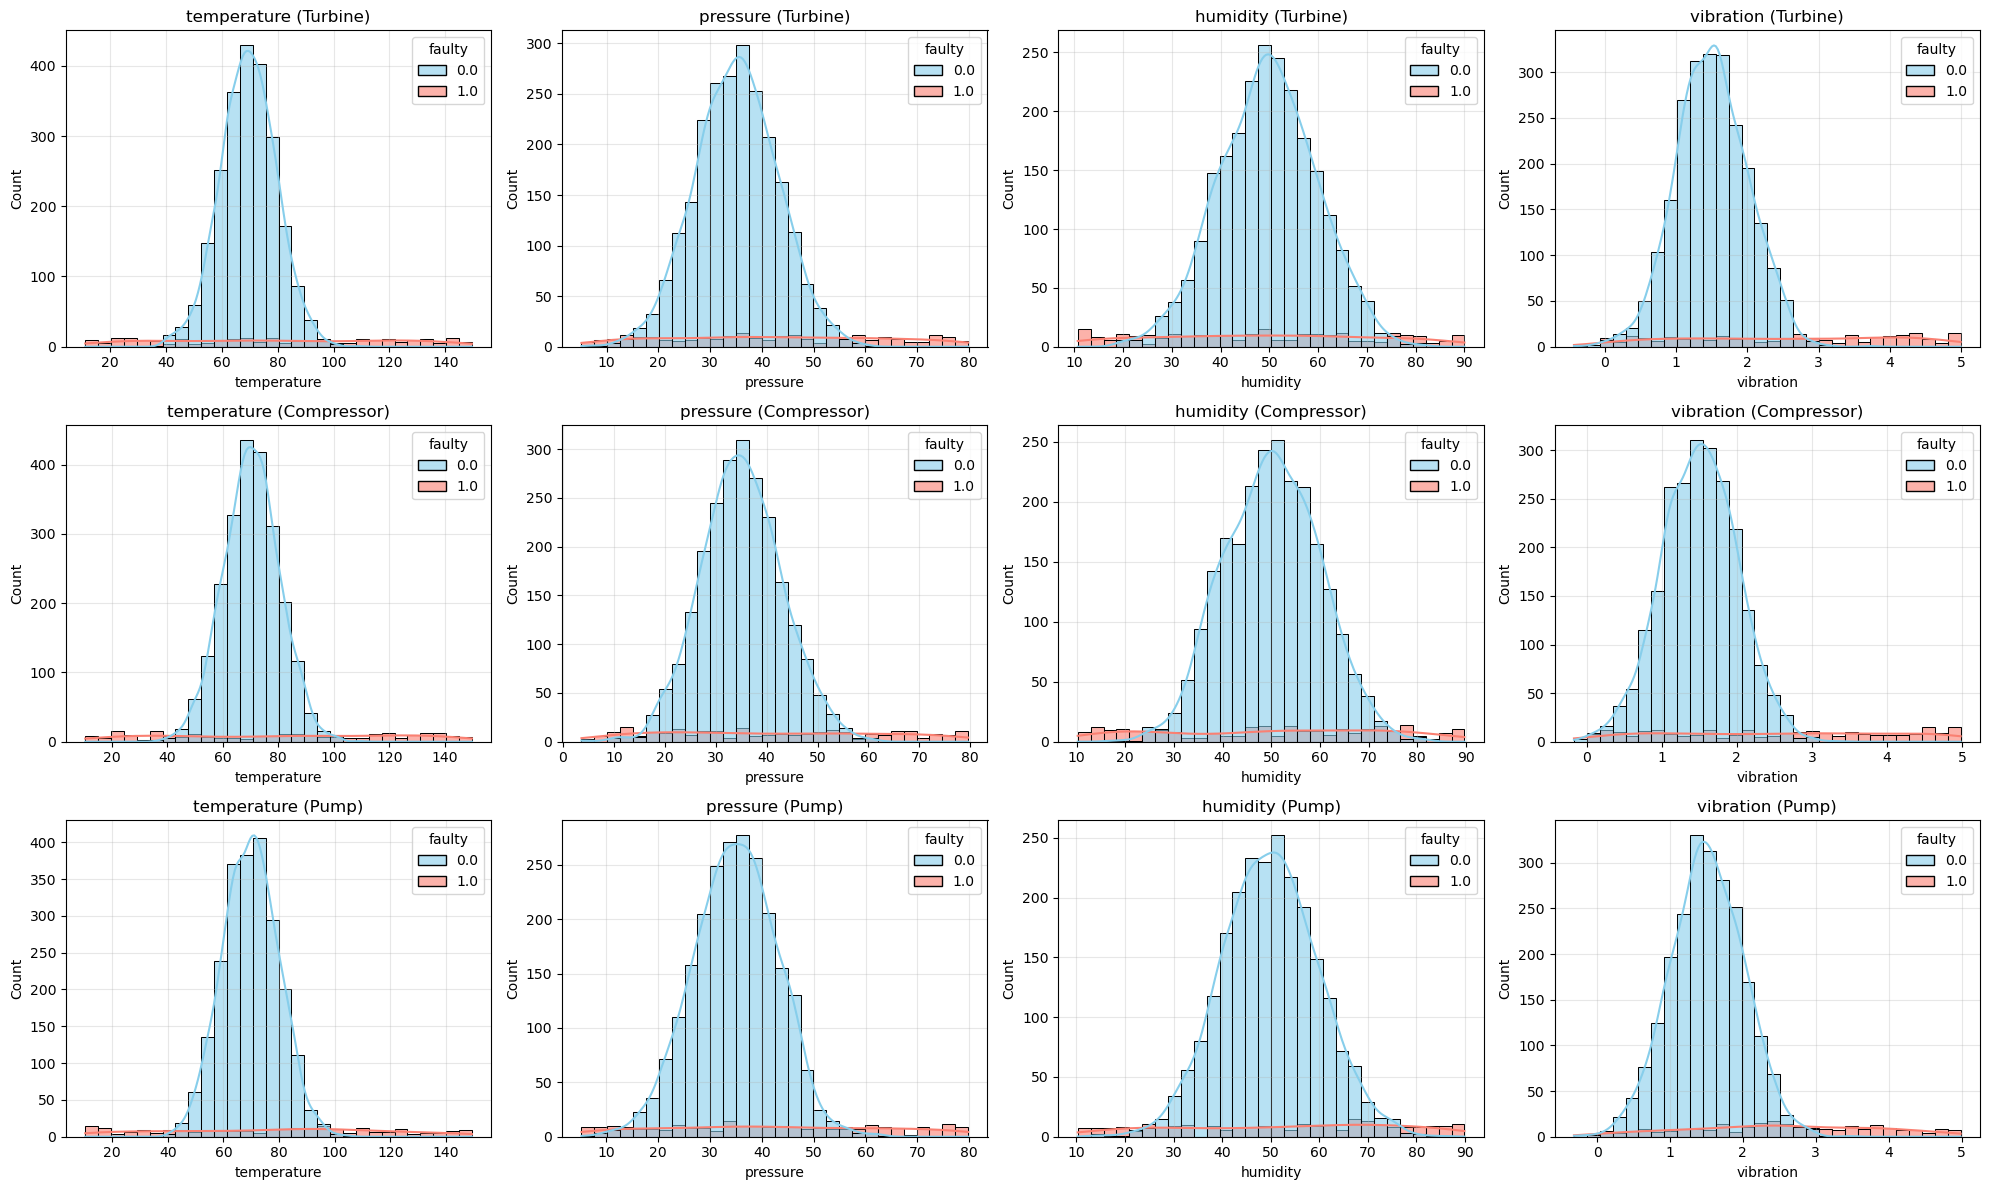

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = 'faulty'
equipment_col = 'equipment'

variables = ['temperature', 'pressure', 'humidity', 'vibration']
equipment_types = data_csv[equipment_col].unique()

fig, axes = plt.subplots(
    len(equipment_types),
    len(variables),
    figsize=(5*len(variables), 4*len(equipment_types))
)

# Fix shape if only one equipment
if len(equipment_types) == 1:
    axes = axes.reshape(1, -1)

for row, eq in enumerate(equipment_types):
    
    subset = data_csv[data_csv[equipment_col] == eq]
    
    for col, var in enumerate(variables):
        
        sns.histplot(
            data=subset,
            x=var,
            hue=target_col,
            bins=30,
            kde=True,
            palette=['skyblue', 'salmon'],
            alpha=0.6,
            ax=axes[row, col]
        )
        
        axes[row, col].set_title(f"{var} ({eq})")
        axes[row, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
no_faulty_data = data_csv[data_csv['faulty'] == 0.0]
no_faulty_equipment = data_csv[data_csv['faulty'] == 0.0]['equipment']
#.drop('equipment',axis = 1)
no_faulty_train, no_faulty_test = train_test_split(no_faulty_data, test_size=0.2, stratify = no_faulty_equipment, shuffle=True, random_state=42)

no_faulty_train = no_faulty_train.drop(['faulty','location','equipment'],axis = 1)

faulty_data = data_csv[data_csv['faulty'] == 1.0]
test = pd.concat([no_faulty_test, faulty_data], ignore_index=True)
test = test.sample(frac=1, random_state=42).reset_index(drop=True)
X_test = test.drop(columns=['faulty']) 
y_test = test['faulty']               
X_test_copy = test.copy()

X_test = X_test.drop(['location','equipment'],axis = 1)


In [8]:
scaler = StandardScaler()

In [9]:
X_train_scaled = scaler.fit_transform(no_faulty_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
ocsvm = OneClassSVM(
    kernel='rbf', 
    gamma='auto', 
    nu=0.05
)

ocsvm.fit(X_train_scaled)


y_pred_ocsvm = ocsvm.predict(X_test_scaled)
y_pred_ocsvm = [0 if i == 1 else 1 for i in y_pred_ocsvm]

              precision    recall  f1-score   support

      Normal       0.97      0.94      0.95      1381
      Faulty       0.89      0.95      0.92       767

    accuracy                           0.94      2148
   macro avg       0.93      0.94      0.94      2148
weighted avg       0.94      0.94      0.94      2148

[[1292   89]
 [  36  731]]


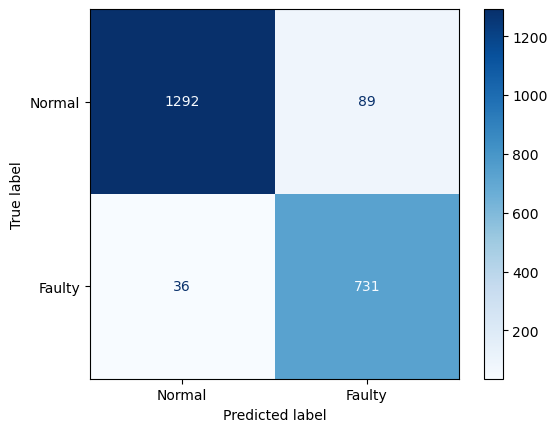

In [14]:
X_test_copy['predictions_osvm'] = y_pred_ocsvm

print(classification_report(y_test, y_pred_ocsvm, target_names=['Normal','Faulty']))

cm_ocsvm = confusion_matrix(y_test, y_pred_ocsvm)
print(cm_ocsvm)

disp_ocsvm = ConfusionMatrixDisplay(cm_ocsvm, display_labels=['Normal','Faulty'])
disp_ocsvm.plot(cmap=plt.cm.Blues)
plt.show()

In [15]:
isoforest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

isoforest.fit(X_train_scaled)


y_pred_isoforest = isoforest.predict(X_test_scaled)
y_pred_isoforest = [0 if i == 1 else 1 for i in y_pred_isoforest]

              precision    recall  f1-score   support

      Normal       0.96      0.95      0.95      1381
      Faulty       0.91      0.93      0.92       767

    accuracy                           0.94      2148
   macro avg       0.93      0.94      0.94      2148
weighted avg       0.94      0.94      0.94      2148

[[1309   72]
 [  53  714]]


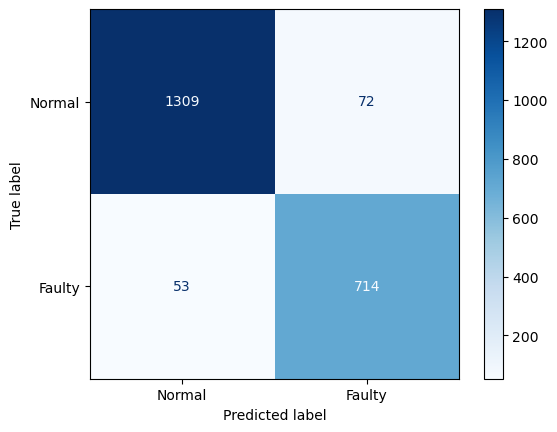

In [16]:
X_test_copy['iso_forest_predictions'] = y_pred_isoforest

print(classification_report(y_test, y_pred_isoforest, target_names=['Normal', 'Faulty']))

cm_isoforest = confusion_matrix(y_test, y_pred_isoforest)
print(cm_isoforest)

disp_isoforest = ConfusionMatrixDisplay(confusion_matrix=cm_isoforest, display_labels=['Normal', 'Faulty'])
disp_isoforest.plot(cmap=plt.cm.Blues)
plt.show()


In [18]:
scores = ocsvm.decision_function(X_test_scaled)
anomaly_scores = -scores

scores_iso = isoforest.decision_function(X_test_scaled)
anomaly_scores_iso = -scores_iso

X_test_copy['ocsvm_anomaly_scores'] = anomaly_scores
X_test_copy['iso_fores_anomaly_scores'] = anomaly_scores_iso

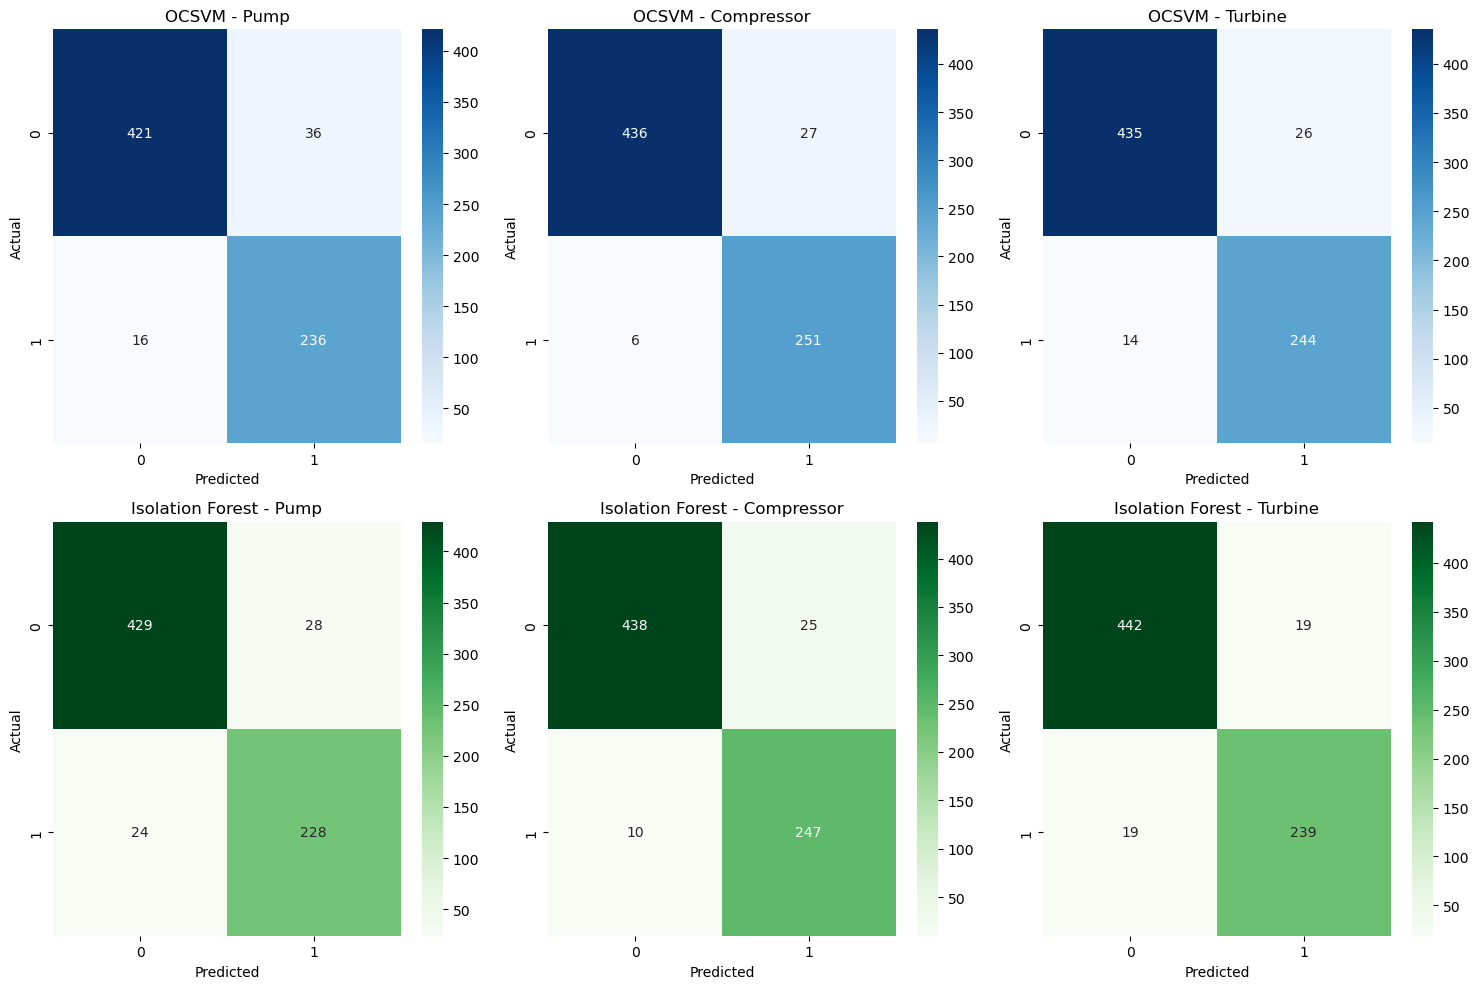

In [19]:
equipment_types = X_test_copy['equipment'].unique()

fig, axes = plt.subplots(
    2, 
    len(equipment_types),
    figsize=(5 * len(equipment_types), 10)  
)

for col, eq in enumerate(equipment_types):
    
    subset = X_test_copy[X_test_copy['equipment'] == eq]
    
    y_true = subset['faulty']
    y_pred_ocsvm = subset['predictions_osvm']
    y_pred_iso = subset['iso_forest_predictions']
    
    cm_ocsvm = confusion_matrix(y_true, y_pred_ocsvm)
    cm_iso = confusion_matrix(y_true, y_pred_iso)
    
    sns.heatmap(cm_ocsvm, annot=True, fmt='d',
                cmap='Blues',
                ax=axes[0, col])
    axes[0, col].set_title(f"OCSVM - {eq}")
    axes[0, col].set_xlabel("Predicted")
    axes[0, col].set_ylabel("Actual")
    
    # Row 1 → Isolation Forest
    sns.heatmap(cm_iso, annot=True, fmt='d',
                cmap='Greens',
                ax=axes[1, col])
    axes[1, col].set_title(f"Isolation Forest - {eq}")
    axes[1, col].set_xlabel("Predicted")
    axes[1, col].set_ylabel("Actual")

plt.tight_layout()
plt.show()

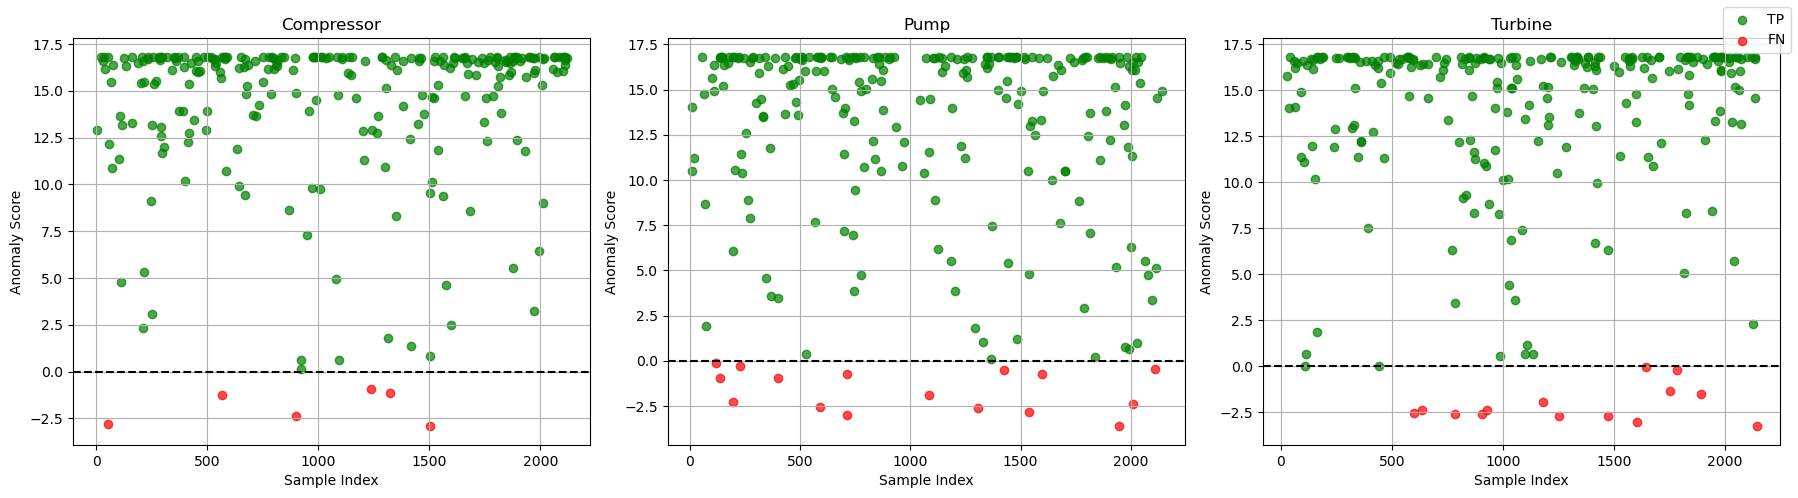

In [21]:

# Ensure clean indexing
plot_df = X_test_copy.reset_index(drop=True)

# Define TP / FN labels
plot_df['label'] = np.where(
    (plot_df['faulty']==1) & (plot_df['predictions_osvm']==1), 'TP',
    np.where(
        (plot_df['faulty']==1) & (plot_df['predictions_osvm']==0), 'FN',
        'Other'
    )
)

# Unique equipments
equipments = sorted(plot_df['equipment'].unique())

# Create 3 subplots (since you have 3 machines)
fig, axes = plt.subplots(1, 3, figsize=(18,5))

colors = {
    'TP': 'green',
    'FN': 'red'
}

for ax, eq in zip(axes, equipments):

    eq_df = plot_df[plot_df['equipment'] == eq]

    # Plot TP + FN only
    for label in ['TP','FN']:

        sub = eq_df[eq_df['label'] == label]

        ax.scatter(
            sub.index,
            sub['ocsvm_anomaly_scores'],
            color=colors[label],
            label=label,
            alpha=0.7
        )

    ax.axhline(0, linestyle='--', color='black')
    ax.set_title(f"{eq}")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Anomaly Score")
    ax.grid(True)

# Add legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import precision_score, recall_score, fbeta_score
import pandas as pd

metrics_results = []

for eq in equipment_types:
    
    subset = X_test_copy[X_test_copy['equipment'] == eq]
    
    y_true = subset['faulty']
    y_pred_ocsvm = subset['predictions_osvm']
    y_pred_iso = subset['iso_forest_predictions']
    
    # --- OCSVM Metrics ---
    precision_oc = precision_score(y_true, y_pred_ocsvm)
    recall_oc = recall_score(y_true, y_pred_ocsvm)
    f2_oc = fbeta_score(y_true, y_pred_ocsvm, beta=2)
    
    metrics_results.append({
        'Equipment': eq,
        'Model': 'OCSVM',
        'Precision': precision_oc,
        'Recall': recall_oc,
        'F2_score': f2_oc
    })
    
    # --- Isolation Forest Metrics ---
    precision_iso = precision_score(y_true, y_pred_iso)
    recall_iso = recall_score(y_true, y_pred_iso)
    f2_iso = fbeta_score(y_true, y_pred_iso, beta=2)
    
    metrics_results.append({
        'Equipment': eq,
        'Model': 'IsolationForest',
        'Precision': precision_iso,
        'Recall': recall_iso,
        'F2_score': f2_iso
    })

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_results)

print("\nModel Performance Per Equipment:\n")
print(metrics_df)


Model Performance Per Equipment:

    Equipment            Model  Precision    Recall  F2_score
0        Pump            OCSVM   0.867647  0.936508  0.921875
1        Pump  IsolationForest   0.890625  0.904762  0.901899
2  Compressor            OCSVM   0.902878  0.976654  0.960949
3  Compressor  IsolationForest   0.908088  0.961089  0.950000
4     Turbine            OCSVM   0.903704  0.945736  0.937020
5     Turbine  IsolationForest   0.926357  0.926357  0.926357



===== BOOTSTRAP RESULTS =====

OCSVM:
Recall: 0.953089960886571 ± 0.0037741250007144326
Precision: 0.8875925194523507 ± 0.006122697978653118
F2: 0.9392138409327313 ± 0.002469015386264325

Isolation Forest:
Recall: 0.929295958279009 ± 0.005122565199823535
Precision: 0.9068431809994647 ± 0.006744648642172305
F2: 0.9247016936084113 ± 0.004036226669031902


C:\Users\ismai\AppData\Local\Temp\ipykernel_36128\582488638.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([metrics_oc[:,0], metrics_if[:,0]],
C:\Users\ismai\AppData\Local\Temp\ipykernel_36128\582488638.py:94: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([metrics_oc[:,1], metrics_if[:,1]],
C:\Users\ismai\AppData\Local\Temp\ipykernel_36128\582488638.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([metrics_oc[:,2], metrics_if[:,2]],


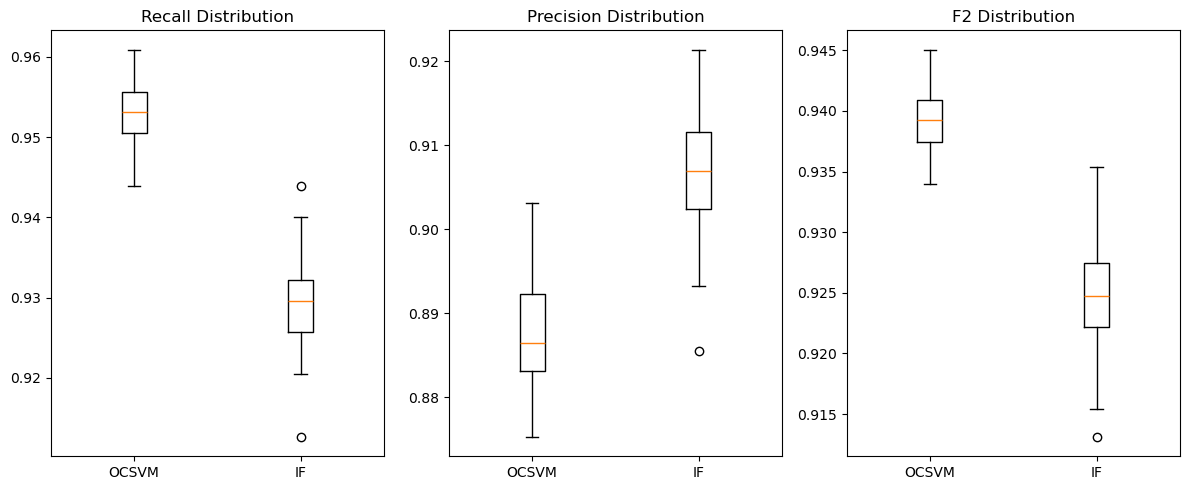

In [25]:
n_runs = 100

X_test = X_test_scaled
y_test = X_test_copy['faulty'].values

# Use only normal training data for anomaly detection training
normal_train = X_train_scaled

# Storage
metrics_oc = []
metrics_if = []

# ---------------------------
# BOOTSTRAP LOOP
# ---------------------------
for i in range(n_runs):

    # Bootstrap training data
    boot_train = resample(
        normal_train,
        replace=True,
        n_samples=len(normal_train),
        random_state=i
    )

    # -------------------
    # Train OCSVM
    # -------------------
    oc = OneClassSVM(
        kernel='rbf',
        gamma='auto',
        nu=0.05
    )

    oc.fit(boot_train)

    pred_oc = (oc.predict(X_test) == -1).astype(int)

    metrics_oc.append([
        recall_score(y_test, pred_oc),
        precision_score(y_test, pred_oc),
        fbeta_score(y_test, pred_oc, beta=2)
    ])

    # -------------------
    # Train Isolation Forest
    # -------------------
    iso = IsolationForest(
        n_estimators=100,
        contamination=0.05,
        random_state=42
    )

    iso.fit(boot_train)

    pred_if = (iso.predict(X_test) == -1).astype(int)

    metrics_if.append([
        recall_score(y_test, pred_if),
        precision_score(y_test, pred_if),
        fbeta_score(y_test, pred_if, beta=2)
    ])

# Convert to arrays
metrics_oc = np.array(metrics_oc)
metrics_if = np.array(metrics_if)

# ---------------------------
# RESULTS
# ---------------------------
print("\n===== BOOTSTRAP RESULTS =====")

print("\nOCSVM:")
print("Recall:", np.mean(metrics_oc[:,0]), "±", np.std(metrics_oc[:,0]))
print("Precision:", np.mean(metrics_oc[:,1]), "±", np.std(metrics_oc[:,1]))
print("F2:", np.mean(metrics_oc[:,2]), "±", np.std(metrics_oc[:,2]))

print("\nIsolation Forest:")
print("Recall:", np.mean(metrics_if[:,0]), "±", np.std(metrics_if[:,0]))
print("Precision:", np.mean(metrics_if[:,1]), "±", np.std(metrics_if[:,1]))
print("F2:", np.mean(metrics_if[:,2]), "±", np.std(metrics_if[:,2]))

# ---------------------------
# VISUALIZATION
# ---------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.boxplot([metrics_oc[:,0], metrics_if[:,0]],
            labels=['OCSVM','IF'])
plt.title("Recall Distribution")

plt.subplot(1,3,2)
plt.boxplot([metrics_oc[:,1], metrics_if[:,1]],
            labels=['OCSVM','IF'])
plt.title("Precision Distribution")

plt.subplot(1,3,3)
plt.boxplot([metrics_oc[:,2], metrics_if[:,2]],
            labels=['OCSVM','IF'])
plt.title("F2 Distribution")

plt.tight_layout()
plt.show()

In [26]:
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import recall_score

n_runs = 100  # more runs for better bootstrap estimate

rec_if = []
rec_oc = []

# Combine normal + faulty data for bootstrapping
full_data = pd.concat([normal_data, faulty_data])

for i in range(n_runs):
    # Bootstrap sample from full data
    boot_sample = resample(full_data, replace=True, n_samples=len(full_data), random_state=i)
    
    # Split into train/test
    X_train = boot_sample[boot_sample['faulty'] == 0].drop(['faulty','location','equipment'], axis=1)
    y_train = boot_sample[boot_sample['faulty'] == 0]['faulty']
    
    test = pd.concat([
        boot_sample[boot_sample['faulty'] == 1],  # all faulty in bootstrap
        boot_sample[boot_sample['faulty'] == 0].sample(frac=0.2, random_state=i)  # subset normal
    ])
    X_test = test.drop(['faulty','location','equipment'], axis=1)
    y_test = test['faulty']
    
    # Isolation Forest
    iso.fit(X_train)
    pred_if = (iso.predict(X_test) == -1).astype(int)
    rec_if.append(recall_score(y_test, pred_if, pos_label=1))
    
    # One-Class SVM
    ocsvm.fit(X_train)
    pred_oc = (ocsvm.predict(X_test) == -1).astype(int)
    rec_oc.append(recall_score(y_test, pred_oc, pos_label=1))

# Summary
print("Isolation Forest mean recall:", np.mean(rec_if), "±", np.std(rec_if))
print("OC-SVM mean recall:", np.mean(rec_oc), "±", np.std(rec_oc))


NameError: name 'normal_data' is not defined

In [27]:
import numpy as np

ci_low_if = np.percentile(rec_if, 2.5)
ci_high_if = np.percentile(rec_if, 97.5)

ci_low_oc = np.percentile(rec_oc, 2.5)
ci_high_oc = np.percentile(rec_oc, 97.5)

print(f"Isolation Forest 95% CI: [{ci_low_if:.3f}, {ci_high_if:.3f}]")
print(f"OC-SVM 95% CI: [{ci_low_oc:.3f}, {ci_high_oc:.3f}]")


IndexError: index -1 is out of bounds for axis 0 with size 0

In [28]:
import time

start = time.time()
isoforest.predict(X_test_scaled)
print("Isolation Forest inference time:", time.time() - start)

start = time.time()
ocsvm.predict(X_test_scaled)
print("OC-SVM inference time:", time.time() - start)


Isolation Forest inference time: 0.02018904685974121
OC-SVM inference time: 0.046019554138183594


In [29]:
import pickle, os

pickle.dump(isoforest, open("iso.pkl","wb"))
pickle.dump(ocsvm, open("ocsvm.pkl","wb"))

print("IF size (KB):", os.path.getsize("iso.pkl")/1024)
print("OC-SVM size (KB):", os.path.getsize("ocsvm.pkl")/1024)


IF size (KB): 1107.5078125
OC-SVM size (KB): 13.9326171875


In [30]:
X_test_noisy = X_test_scaled + np.random.normal(0, 0.01, X_test_scaled.shape)

pred_if = (isoforest.predict(X_test_noisy) == -1).astype(int)
pred_oc = (ocsvm.predict(X_test_noisy) == -1).astype(int)

print("IF noisy recall:",
      recall_score(y_test, pred_if, pos_label=1))

print("OC noisy recall:",
      recall_score(y_test, pred_oc, pos_label=1))


IF noisy recall: 0.9308996088657105
OC noisy recall: 0.9530638852672751


In [31]:
import shap
shap.initjs()

In [ ]:
subset = X_test_scaled[:1000]  
explainer = shap.KernelExplainer(lambda x: ocsvm.decision_function(x), X_train_scaled)
shap_values = explainer.shap_values(subset)


subset = X_test_scaled[:1000]  
explainer = shap.KernelExplainer(lambda x: iso_forest.decision_function(x), X_train_scaled)
shap_values = explainer.shap_values(subset)

In [34]:

# Subset for explanation
subset = X_test_scaled[:1000]

explainer_ocsvm = shap.KernelExplainer(
    lambda x: ocsvm.decision_function(x),
    X_train_scaled
)

shap_values_ocsvm = explainer_ocsvm.shap_values(subset)

Using 5524 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [17:01<00:00,  1.02s/it]


In [36]:
explainer_isoforest = shap.KernelExplainer(
    lambda x: isoforest.decision_function(x),
    X_train_scaled
)

Using 5524 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


In [37]:
shap_values_isoforest = explainer_isoforest.shap_values(X_test_scaled)

100%|██████████████████████████████████████████████████████████████████████████████| 2148/2148 [06:51<00:00,  5.22it/s]


In [77]:
import numpy as np

np.save("shap_values_isoforest.npy", shap_values_isoforest)

In [50]:
feature_names = [
    'isoforest_shap_temperature',
    'isoforest_shap_pressure',
    'isoforest_shap_vibration',
    'isoforest_shap_humidity'
]

shap_df = pd.DataFrame(
    shap_values_isoforest,
    columns=feature_names,
    index=X_test_copy.index
)

# Merge SHAP values into test dataframe
X_test_copy = pd.concat([X_test_copy, shap_df], axis=1)

In [42]:
X_test_scaled.columns

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [55]:
shap_values_ocsvm = explainer_ocsvm.shap_values(X_test_scaled)

100%|██████████████████████████████████████████████████████████████████████████████| 2148/2148 [36:36<00:00,  1.02s/it]


In [76]:
import numpy as np

np.save("shap_values_ocsvm.npy", shap_values_ocsvm)

In [56]:
feature_names_ocsvm = [
    'ocsvm_shap_temperature',
    'ocsvm_shap_pressure',
    'ocsvm_shap_vibration',
    'ocsvm_shap_humidity'
]

shap_df_ocsvm = pd.DataFrame(
    shap_values_ocsvm,
    columns=feature_names_ocsvm,
    index=X_test_copy.index
)

# Merge SHAP values into test dataframe
X_test_copy = pd.concat([X_test_copy, shap_df_ocsvm], axis=1)

In [58]:
X_test_copy.to_csv("X_test_copy.csv", index=False)

In [78]:
X_test_copy.to_csv("Fault_detection_project_results.csv", index=False)

In [79]:
X_test_copy

,temperature,pressure,vibration,humidity,equipment,location,faulty,predictions_osvm,iso_forest_predictions,ocsvm_anomaly_scores,iso_fores_anomaly_scores,isoforest_shap_temperature,isoforest_shap_pressure,isoforest_shap_vibration,isoforest_shap_humidity,ocsvm_shap_temperature,ocsvm_shap_pressure,ocsvm_shap_vibration,ocsvm_shap_humidity
0,91.430071,27.030486,0.336200,44.298876,Pump,New York,0.0,1,1,1.479704,0.055106,-0.073983,-0.006129,-0.082128,0.011251,-1.765506,0.066970,-2.364363,0.547855
1,55.984287,68.731876,0.249952,49.387285,Compressor,New York,1.0,1,1,12.883122,0.096179,-0.017141,-0.099452,-0.090996,0.015528,-0.397454,-12.141336,-2.816048,0.436375
2,62.831777,35.743485,2.823942,25.762527,Pump,Atlanta,0.0,1,1,5.091548,0.045169,0.008755,0.018256,-0.082907,-0.085155,0.398725,0.602356,-4.537472,-3.590497
3,64.172413,31.871803,0.887800,69.478910,Turbine,Chicago,0.0,0,0,-2.047813,-0.041680,0.011224,0.016548,-0.021112,-0.060862,0.253426,0.298264,0.060204,-0.599422
4,57.355016,36.611156,0.524961,68.289096,Pump,San Francisco,0.0,1,1,0.417389,0.012366,-0.009113,0.012450,-0.064517,-0.047068,-0.210663,0.538665,-1.443543,-1.337189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2143,53.110965,32.892851,1.755319,52.095904,Turbine,Atlanta,1.0,0,0,-3.263523,-0.128794,-0.028906,0.019862,0.021815,0.020141,0.901402,0.121261,0.124833,0.080686
2144,56.414260,42.467384,1.279488,51.740560,Compressor,San Francisco,0.0,0,0,-3.255846,-0.113812,-0.017150,0.001376,0.013761,0.019943,0.696784,0.251293,0.187103,0.085326
2145,61.519344,33.058668,1.516969,49.700566,Turbine,New York,0.0,0,0,-1.612284,-0.161928,0.005222,0.020021,0.021592,0.019211,0.264536,-0.200134,-0.218396,-0.269062
2146,62.646965,22.138870,1.338969,47.452812,Pump,San Francisco,0.0,0,0,-2.762112,-0.104913,0.007101,-0.030273,0.015435,0.016768,0.092455,0.369409,0.188891,0.076016



Equipment: Pump


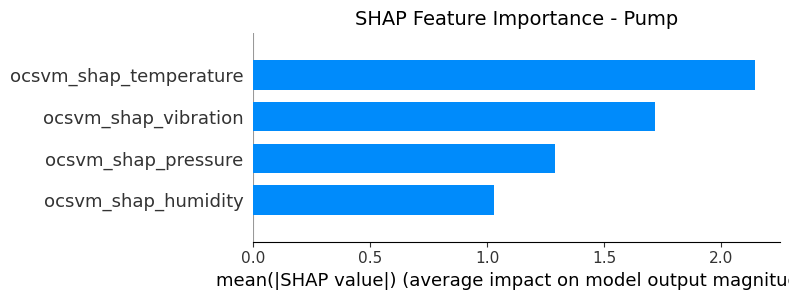


Equipment: Compressor


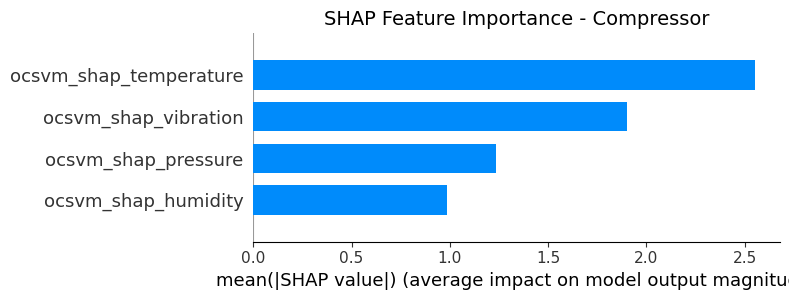


Equipment: Turbine


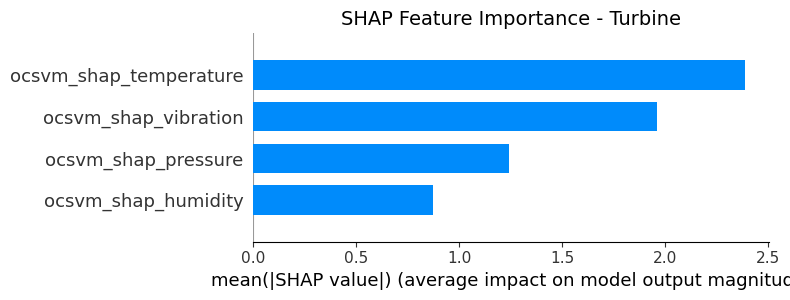

In [64]:
for eq in X_test_copy['equipment'].unique():

    print(f"\nEquipment: {eq}")

    idx = X_test_copy[X_test_copy['equipment'] == eq].index

    # Create figure first ⭐
    plt.figure(figsize=(10,6))

    shap.summary_plot(
        shap_values_ocsvm[idx],
        X_test_scaled[idx],
        feature_names=feature_names_ocsvm,
        plot_type="bar",
        show=False   # VERY IMPORTANT ⭐
    )

    plt.title(f"SHAP Feature Importance - {eq}", fontsize=14)
    plt.tight_layout()
    plt.show()


Equipment: Pump


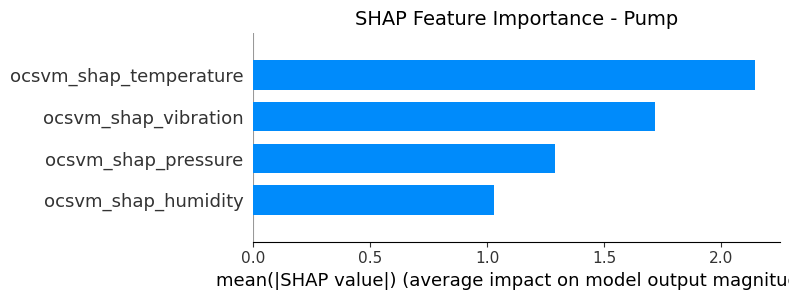


Equipment: Compressor


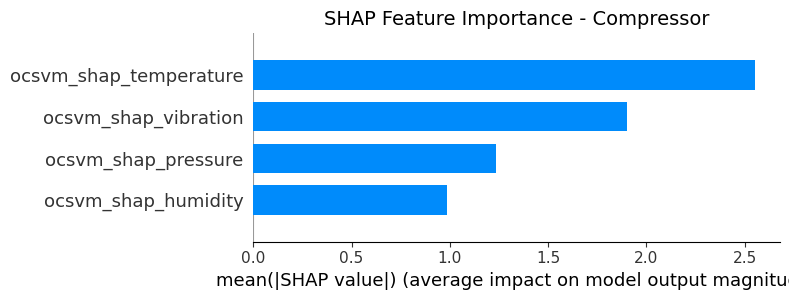


Equipment: Turbine


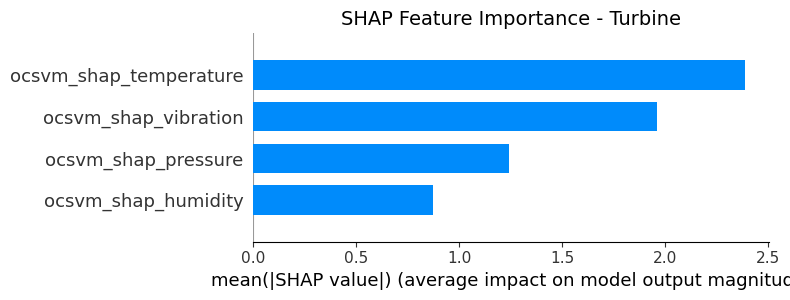

In [75]:
import os

# Create folder to store plots
os.makedirs("shap_plots_equipment", exist_ok=True)

for eq in X_test_copy['equipment'].unique():

    print(f"\nEquipment: {eq}")

    idx = X_test_copy[X_test_copy['equipment'] == eq].index

    plt.figure(figsize=(10,6))

    shap.summary_plot(
        shap_values_ocsvm[idx],
        X_test_scaled[idx],
        feature_names=feature_names_ocsvm,
        plot_type="bar",
        show=False
    )

    plt.title(f"SHAP Feature Importance - {eq}", fontsize=14)
    plt.tight_layout()

    # Save plot ⭐
    plt.savefig(f"shap_plots_equipment/shap_bar_{eq}.png", dpi=300)

    plt.show()

In [ ]:
import os

# Create folder to store plots
os.makedirs("shap_plots_equipment", exist_ok=True)

for eq in X_test_copy['equipment'].unique():

    print(f"\nEquipment: {eq}")

    idx = X_test_copy[X_test_copy['equipment'] == eq].index

    plt.figure(figsize=(10,6))

    shap.summary_plot(
        shap_values_ocsvm[idx],
        X_test_scaled[idx],
        feature_names=feature_names_ocsvm,
        plot_type="bar",
        show=False
    )

    plt.title(f"SHAP Feature Importance - {eq}", fontsize=14)
    plt.tight_layout()

    # Save plot ⭐
    plt.savefig(f"shap_plots_equipment/shap_bar_{eq}.png", dpi=300)

    plt.show()

AssertionError: 'shap_values' must have the same number of columns as 'features'!

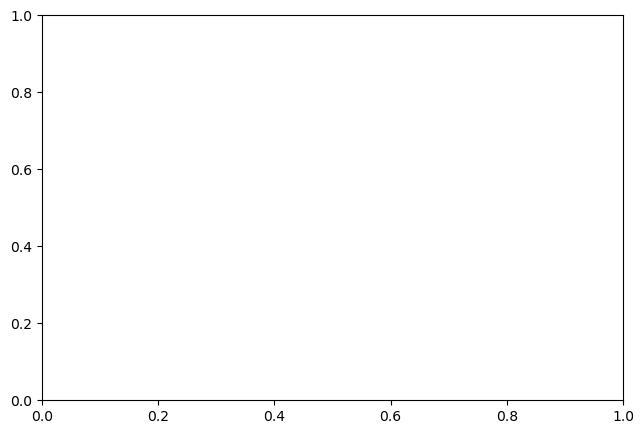

In [70]:
shap.dependence_plot(
    "ocsvm_shap_temperature",
    shap_values_ocsvm,
    X_test_copy,
    feature_names=feature_names_ocsvm
)


Optimal nu: 0.0140
FP: 29
FN: 57
Total Error: 86


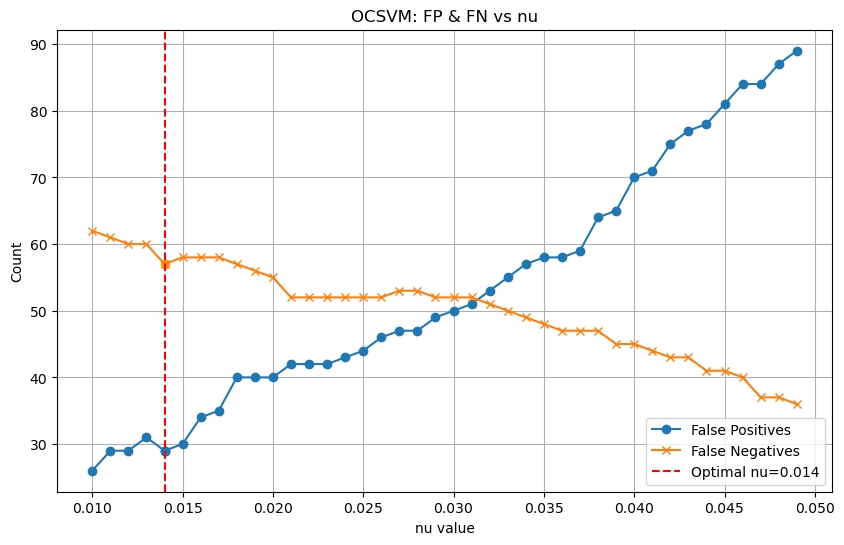

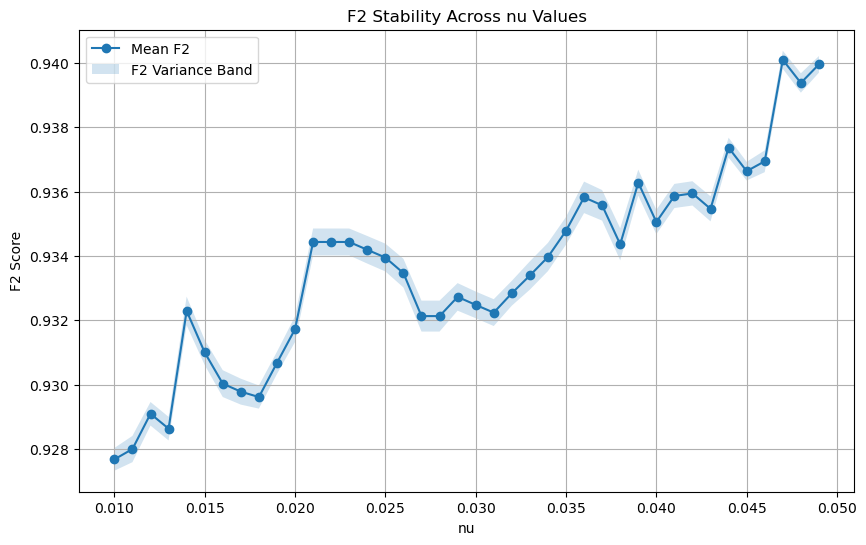


Equipment Level F2 Statistics:

Pump
Mean F2: 0.9131
Variance F2: 0.000011

Compressor
Mean F2: 0.9604
Variance F2: 0.000007

Turbine
Mean F2: 0.9273
Variance F2: 0.000025


In [73]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import confusion_matrix, fbeta_score
import numpy as np
import matplotlib.pyplot as plt

# Parameter grid
nu_values = np.arange(0.01, 0.05, 0.001)

FP_list = []
FN_list = []

equipment_list = X_test_copy['equipment'].unique()

# Store F2 per equipment
f2_equipment_results = {eq: [] for eq in equipment_list}

# Store mean + variance F2
f2_mean_list = []
f2_var_list = []

y_test = X_test_copy['faulty'].values

# -----------------------------
# Hyperparameter Search Loop
# -----------------------------
for nu in nu_values:

    ocsvm = OneClassSVM(
        kernel='rbf',
        gamma='auto',
        nu=nu
    )

    ocsvm.fit(X_train_scaled)

    y_pred = ocsvm.predict(X_test_scaled)
    y_pred_binary = np.where(y_pred == -1, 1, 0)

    # Overall confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_binary
    ).ravel()

    FP_list.append(fp)
    FN_list.append(fn)

    # -----------------------------
    # Equipment Level F2 Analysis ⭐
    # -----------------------------
    f2_scores_equipment = []

    for eq in equipment_list:

        idx = X_test_copy[X_test_copy['equipment'] == eq].index

        if len(idx) > 0:

            f2 = fbeta_score(
                y_test[idx],
                y_pred_binary[idx],
                beta=2
            )

            f2_equipment_results[eq].append(f2)
            f2_scores_equipment.append(f2)

    # Mean + variance across equipment
    f2_mean_list.append(np.mean(f2_scores_equipment))
    f2_var_list.append(np.var(f2_scores_equipment))

# -----------------------------
# Optimal Nu Selection
# -----------------------------
total_error = np.array(FP_list) + np.array(FN_list)

best_idx = np.argmin(total_error)
best_nu = nu_values[best_idx]

print(f"\nOptimal nu: {best_nu:.4f}")
print(f"FP: {FP_list[best_idx]}")
print(f"FN: {FN_list[best_idx]}")
print(f"Total Error: {total_error[best_idx]}")

# -----------------------------
# Plot FP / FN Curve
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(nu_values, FP_list, label="False Positives", marker='o')
plt.plot(nu_values, FN_list, label="False Negatives", marker='x')

plt.axvline(
    best_nu,
    color='red',
    linestyle='--',
    label=f'Optimal nu={best_nu:.3f}'
)

plt.scatter(best_nu, FP_list[best_idx], color='blue')
plt.scatter(best_nu, FN_list[best_idx], color='orange')

plt.xlabel("nu value")
plt.ylabel("Count")
plt.title("OCSVM: FP & FN vs nu")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# F2 Stability Plot
# -----------------------------
plt.figure(figsize=(10,6))

plt.plot(nu_values, f2_mean_list,
         label="Mean F2", marker='o')

plt.fill_between(
    nu_values,
    np.array(f2_mean_list) - np.array(f2_var_list),
    np.array(f2_mean_list) + np.array(f2_var_list),
    alpha=0.2,
    label="F2 Variance Band"
)

plt.xlabel("nu")
plt.ylabel("F2 Score")
plt.title("F2 Stability Across nu Values")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# Equipment Level Statistics
# -----------------------------
print("\nEquipment Level F2 Statistics:")

for eq in equipment_list:

    arr = np.array(f2_equipment_results[eq])

    print(f"\n{eq}")
    print(f"Mean F2: {np.mean(arr):.4f}")
    print(f"Variance F2: {np.var(arr):.6f}")


Optimal contamination: 0.0320
FP: 48
FN: 66
Total error: 114


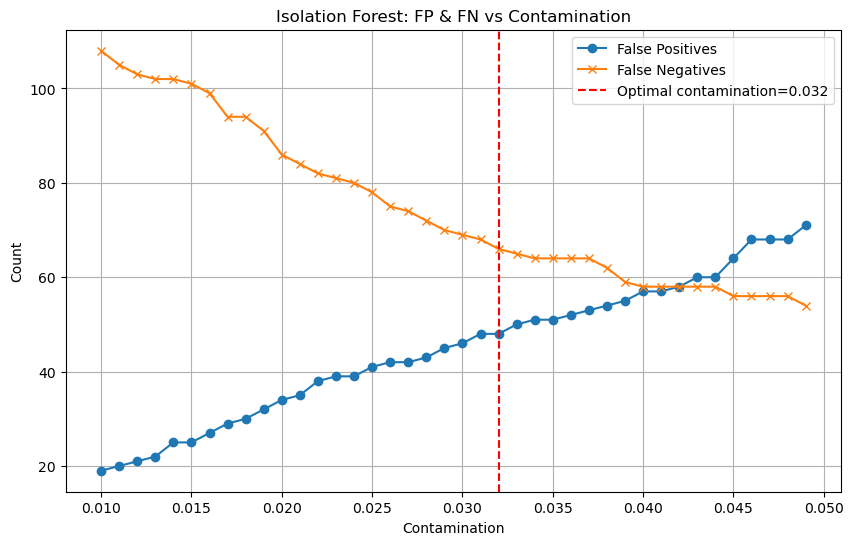

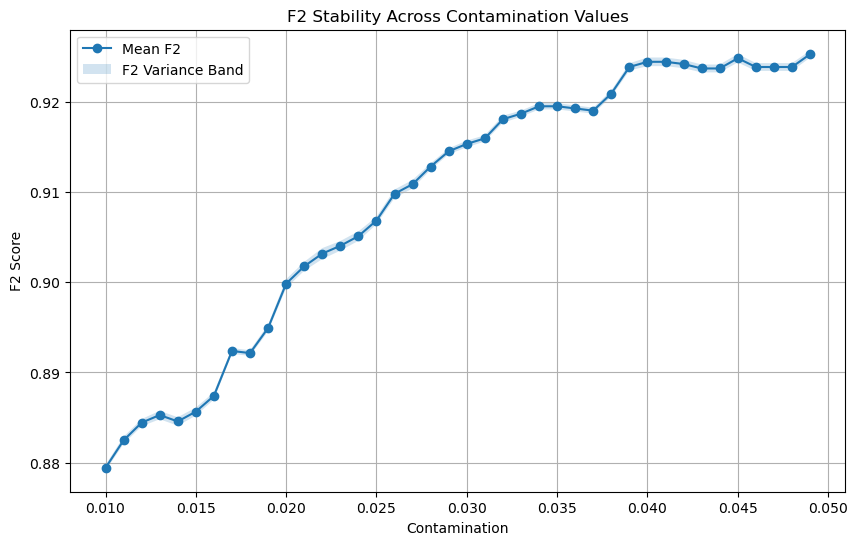


Equipment Level F2 Statistics:

Pump
Mean F2: 0.8863
Variance F2: 0.000190

Compressor
Mean F2: 0.9354
Variance F2: 0.000210

Turbine
Mean F2: 0.9059
Variance F2: 0.000280


In [72]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, fbeta_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameter grid
contamination_values = np.arange(0.01, 0.05, 0.001)

FP_list = []
FN_list = []

# Store F2 results per equipment
equipment_list = X_test_copy['equipment'].unique()
f2_equipment_results = {eq: [] for eq in equipment_list}

# Store mean + variance F2 per parameter
f2_mean_list = []
f2_var_list = []

y_test = X_test_copy['faulty'].values

for cont in contamination_values:

    iso = IsolationForest(
        n_estimators=100,
        contamination=cont,
        random_state=42
    )

    iso.fit(X_train_scaled)

    y_pred = iso.predict(X_test_scaled)
    y_pred_binary = np.where(y_pred == -1, 1, 0)

    # Overall FP/FN
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_binary).ravel()

    FP_list.append(fp)
    FN_list.append(fn)

    # Equipment level F2 analysis ⭐⭐⭐⭐⭐
    f2_scores_equipment = []

    for eq in equipment_list:

        idx = X_test_copy[X_test_copy['equipment'] == eq].index

        if len(idx) > 0:

            f2 = fbeta_score(
                y_test[idx],
                y_pred_binary[idx],
                beta=2
            )

            f2_equipment_results[eq].append(f2)
            f2_scores_equipment.append(f2)

    # Mean + variance across equipments
    f2_mean_list.append(np.mean(f2_scores_equipment))
    f2_var_list.append(np.var(f2_scores_equipment))

# ==========================
# Best parameter selection
# ==========================
total_error = np.array(FP_list) + np.array(FN_list)

best_idx = np.argmin(total_error)
best_cont = contamination_values[best_idx]

print(f"\nOptimal contamination: {best_cont:.4f}")
print(f"FP: {FP_list[best_idx]}")
print(f"FN: {FN_list[best_idx]}")
print(f"Total error: {total_error[best_idx]}")

# ==========================
# Plot FP FN Curve
# ==========================
plt.figure(figsize=(10,6))

plt.plot(contamination_values, FP_list, label="False Positives", marker='o')
plt.plot(contamination_values, FN_list, label="False Negatives", marker='x')

plt.axvline(best_cont, color='red', linestyle='--',
            label=f'Optimal contamination={best_cont:.3f}')

plt.xlabel("Contamination")
plt.ylabel("Count")
plt.title("Isolation Forest: FP & FN vs Contamination")
plt.legend()
plt.grid()
plt.show()

# ==========================
# Plot Mean + Variance F2 Across Parameters
# ==========================
plt.figure(figsize=(10,6))

plt.plot(contamination_values, f2_mean_list,
         label="Mean F2", marker='o')

plt.fill_between(
    contamination_values,
    np.array(f2_mean_list) - np.array(f2_var_list),
    np.array(f2_mean_list) + np.array(f2_var_list),
    alpha=0.2,
    label="F2 Variance Band"
)

plt.xlabel("Contamination")
plt.ylabel("F2 Score")
plt.title("F2 Stability Across Contamination Values")
plt.legend()
plt.grid()
plt.show()

# ==========================
# Print Equipment Level Statistics
# ==========================
print("\nEquipment Level F2 Statistics:")

for eq in equipment_list:

    arr = np.array(f2_equipment_results[eq])

    print(f"\n{eq}")
    print(f"Mean F2: {np.mean(arr):.4f}")
    print(f"Variance F2: {np.var(arr):.6f}")

In [74]:
import joblib

# Save SHAP explainers
joblib.dump(explainer_ocsvm, "explainer_ocsvm.pkl")
joblib.dump(explainer_isoforest, "explainer_isoforest.pkl")

# Save SHAP values
np.save("shap_values_ocsvm.npy", shap_values_ocsvm)
np.save("shap_values_isoforest.npy", shap_values_isoforest)

PicklingError: Can't pickle <function <lambda> at 0x000001EC63DE93F0>: it's not found as __main__.<lambda>